# **===========   🧠 Detection -Luna16   ===========**

In [36]:

# 1. Imports et Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import cv2
from scipy.ndimage import zoom, binary_fill_holes
from sklearn.model_selection import train_test_split
from tqdm import tqdm



# <b>1 <span style='color:#B5A8D5'>|</span> Data Exploration  </b>

In [35]:
annotations = pd.read_csv("/kaggle/input/luna-16/LUNA_16/annotations.csv")
candidates = pd.read_csv("/kaggle/input/luna-16/LUNA_16/candidates_V2.csv")
dataset_path = "/kaggle/input/luna-16/LUNA_16"

In [5]:
annotations.head()

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


In [6]:
candidates.head()

,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


## 📊 Data Loading and Preparation

## 📋 Dataset Overview

### Annotations Dataset Summary

,Attribute,Value
0,Rows,"1,186"
1,Columns,5
2,Memory Usage,0.17 MB
3,Missing Values,0 (0.00%)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seriesuid,1186,601,1.3.6.1.4.1.14519.5.2.1.6279.6001.176030616406...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coordX,1186.0,NaN,NaN,NaN,-5.067547,84.468115,-164.351031,-80.909225,-32.855132,76.830069,164.763985
coordY,1186.0,NaN,NaN,NaN,8.428113,98.316003,-283.834336,-51.549643,18.787926,67.245915,271.405521
coordZ,1186.0,NaN,NaN,NaN,-160.159029,279.829437,-790.074799,-221.197808,-167.61516,-109.735281,1790.494057
diameter_mm,1186.0,NaN,NaN,NaN,8.306527,4.762033,3.253443,5.107177,6.4336,9.696301,32.27003


...

### Candidates Dataset Summary

,Attribute,Value
0,Rows,"754,975"
1,Columns,5
2,Memory Usage,110.16 MB
3,Missing Values,0 (0.00%)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seriesuid,754975,888,1.3.6.1.4.1.14519.5.2.1.6279.6001.652347820272...,2066,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coordX,754975.0,NaN,NaN,NaN,-2.633154,71.215354,-187.77,-61.76,-17.34,60.72,217.43329
coordY,754975.0,NaN,NaN,NaN,4.841814,92.676709,-321.63,-43.642962,16.6,57.677198,294.5
coordZ,754975.0,NaN,NaN,NaN,-158.963584,280.076072,-895.22,-226.550959,-172.73,-120.004883,1906.140031
class,754975.0,NaN,NaN,NaN,0.002062,0.045366,0.0,0.0,0.0,0.0,1.0


,Data Type,Count
0,float64,3
1,object,1
2,int64,1


## 🔍 Missing Data Analysis

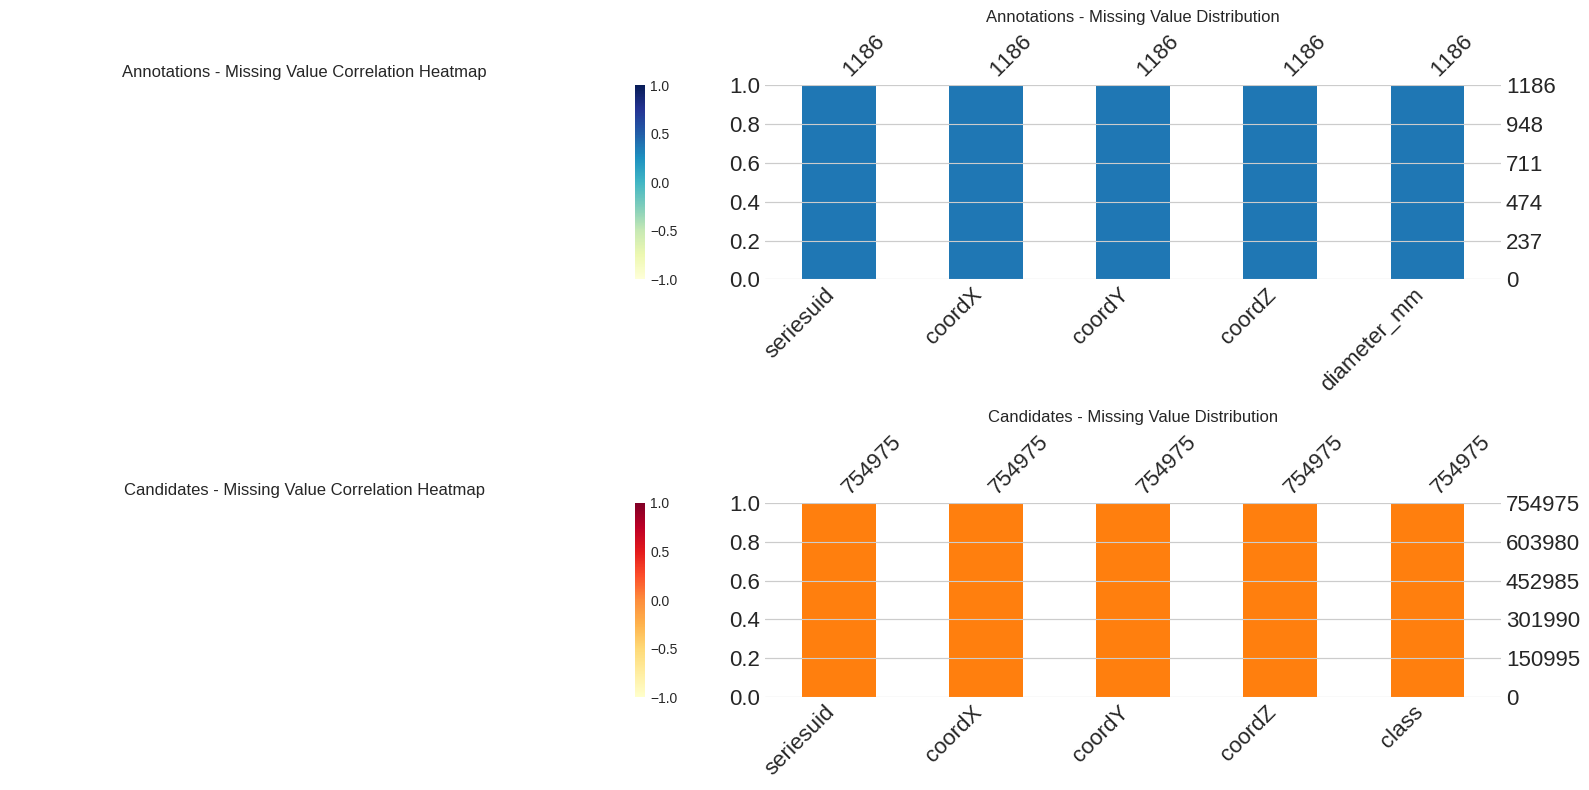

## 📊 Class Distribution Analysis

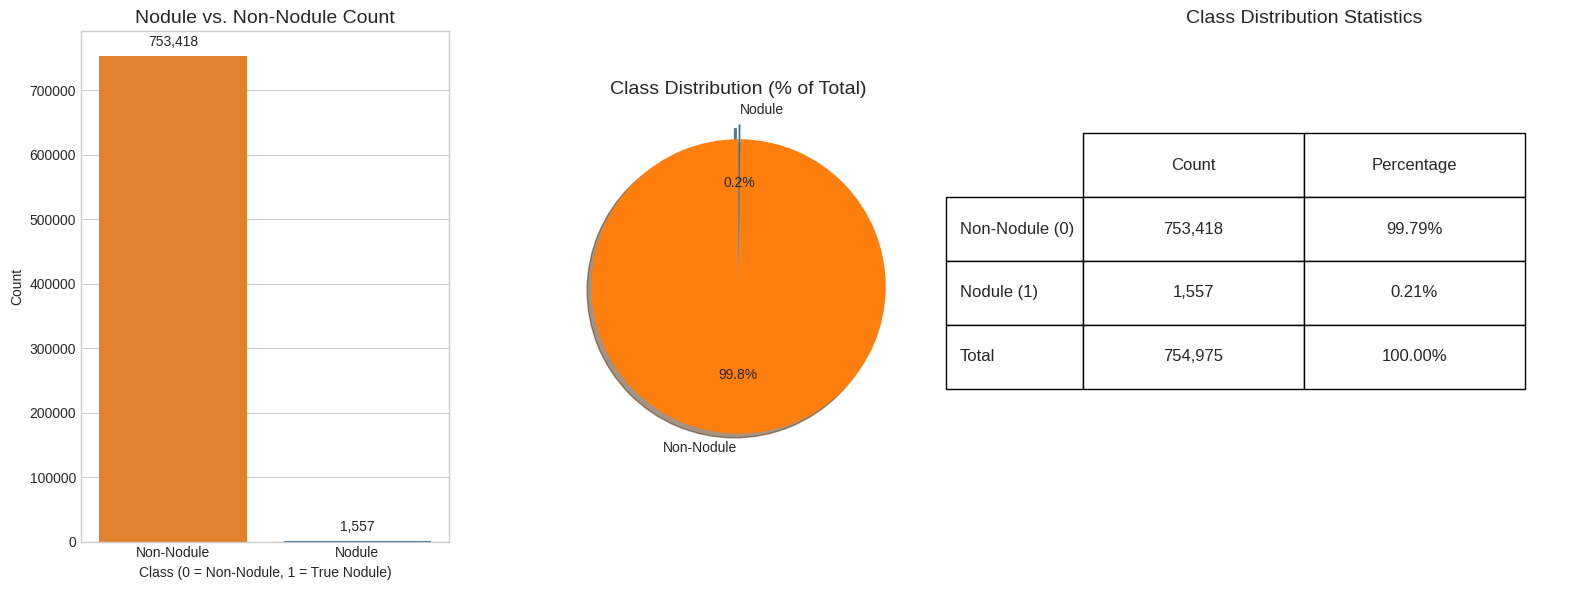

**Class Imbalance Ratio (Non-Nodule : Nodule)**: 483.89 : 1

## 📏 Nodule Size Analysis

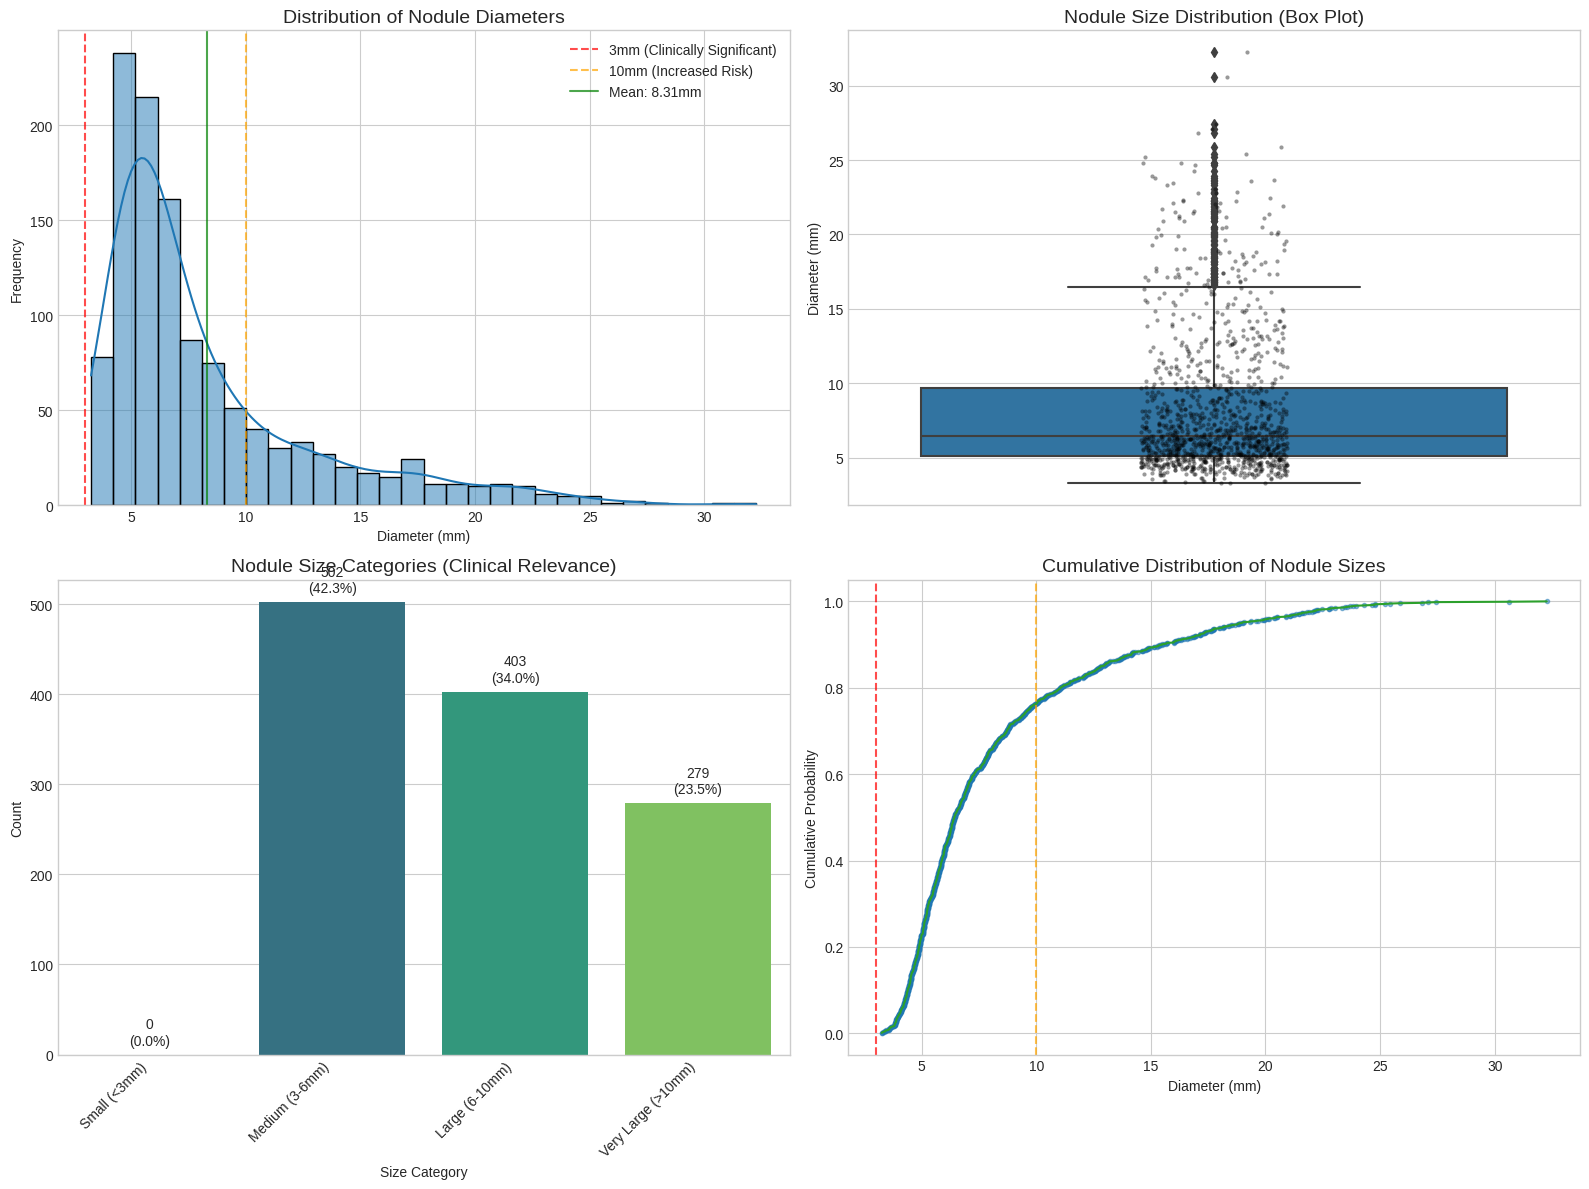

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
diameter_mm,1186.0,8.306527,4.762033,3.253443,5.107177,6.4336,9.696301,32.27003,1.747964,2.847341


## 📍 Nodule Position Analysis

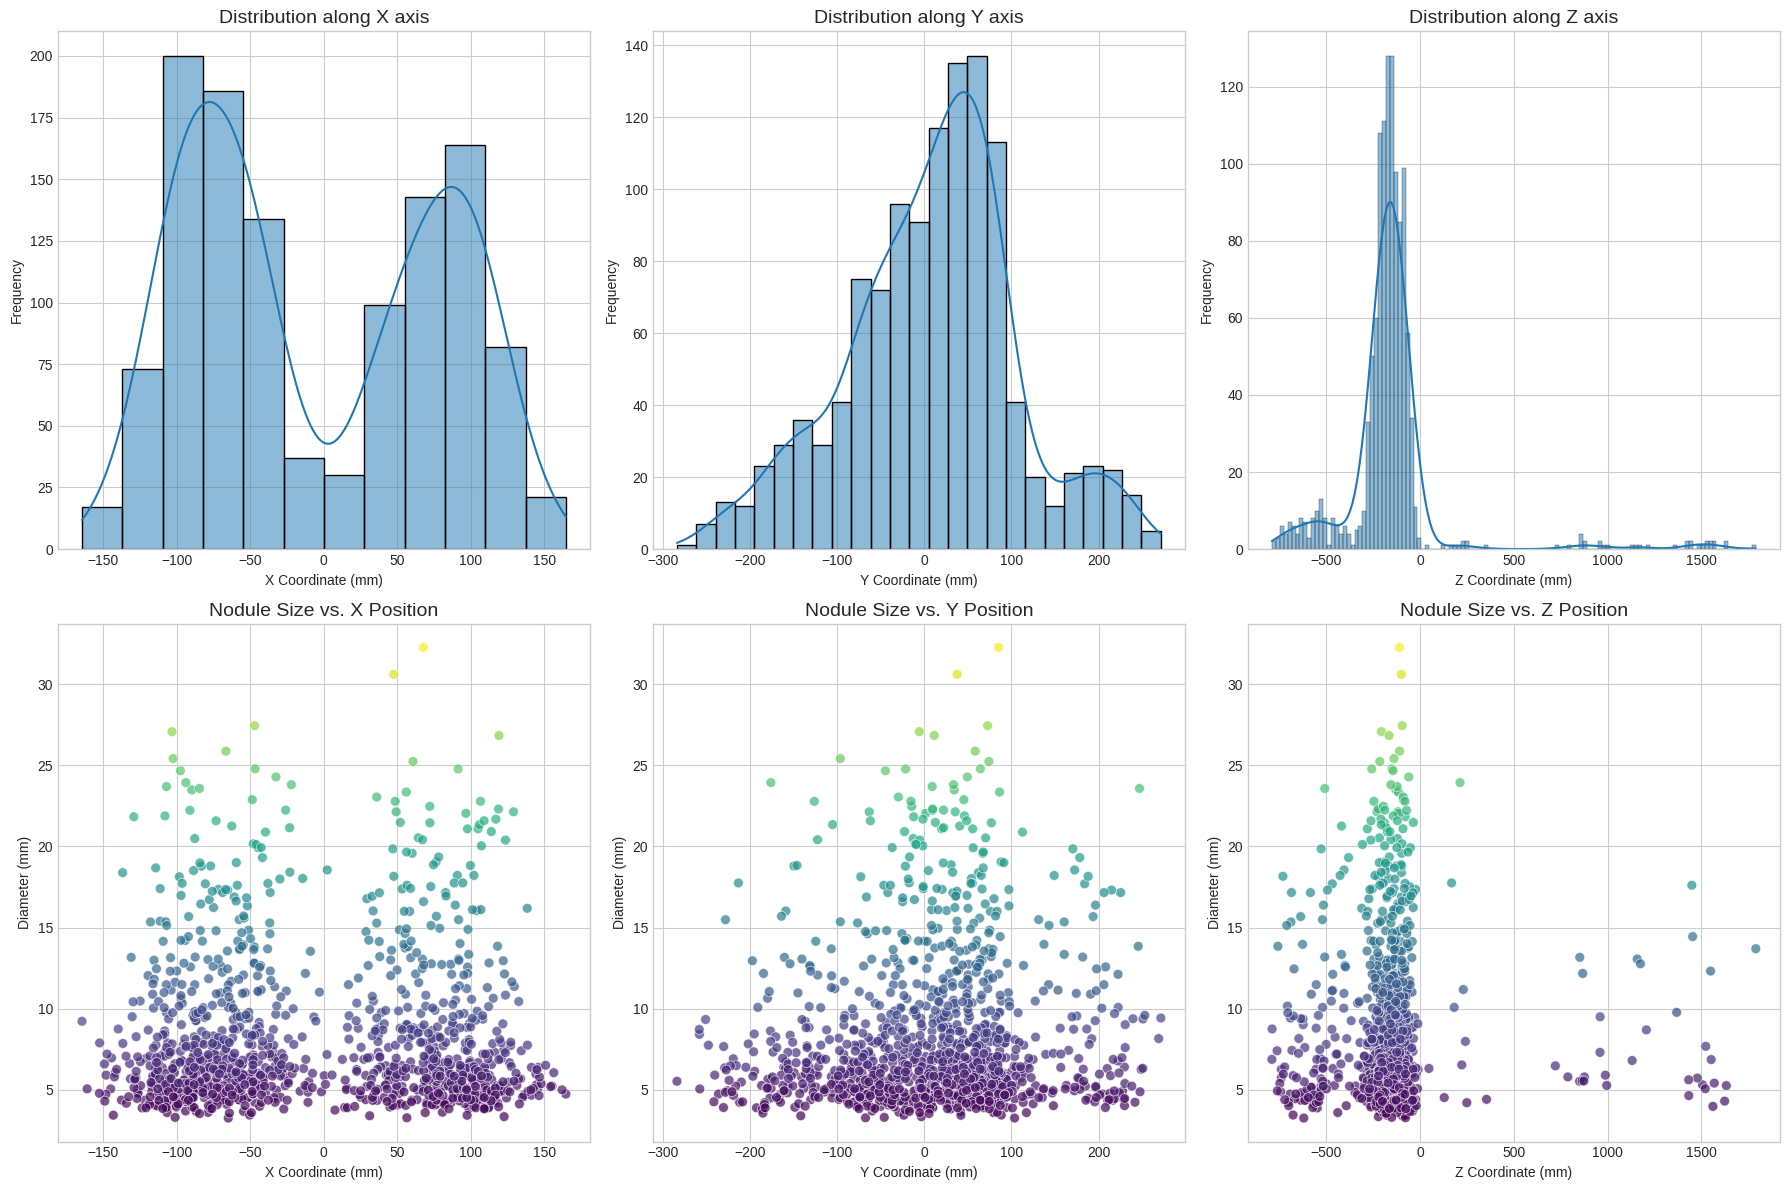

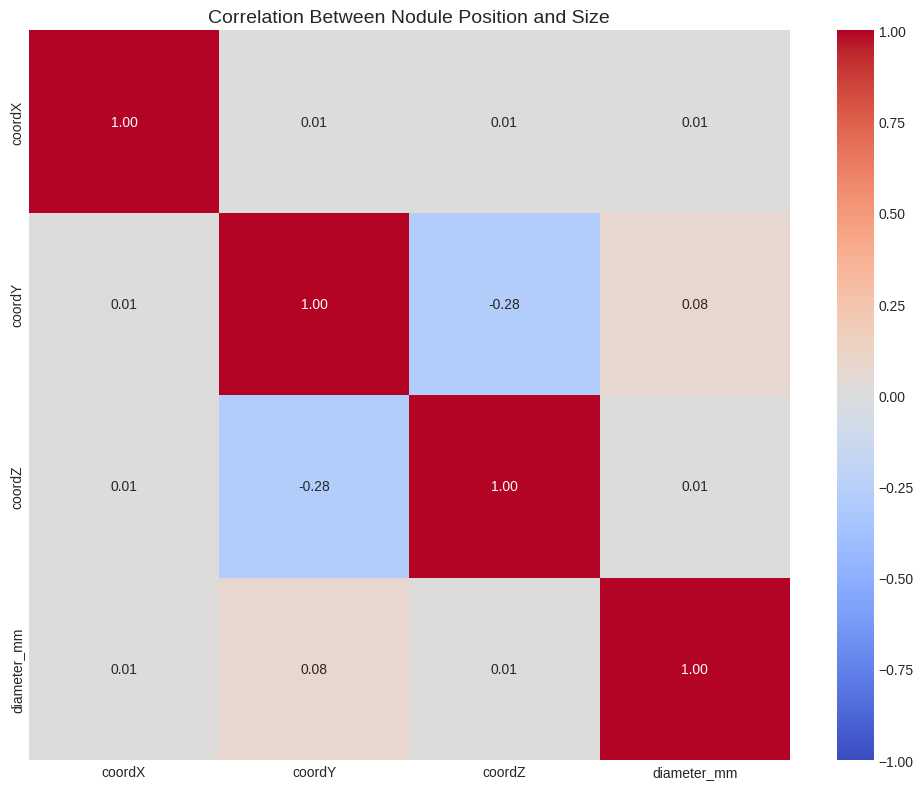

## 👤 Patient-Level Analysis

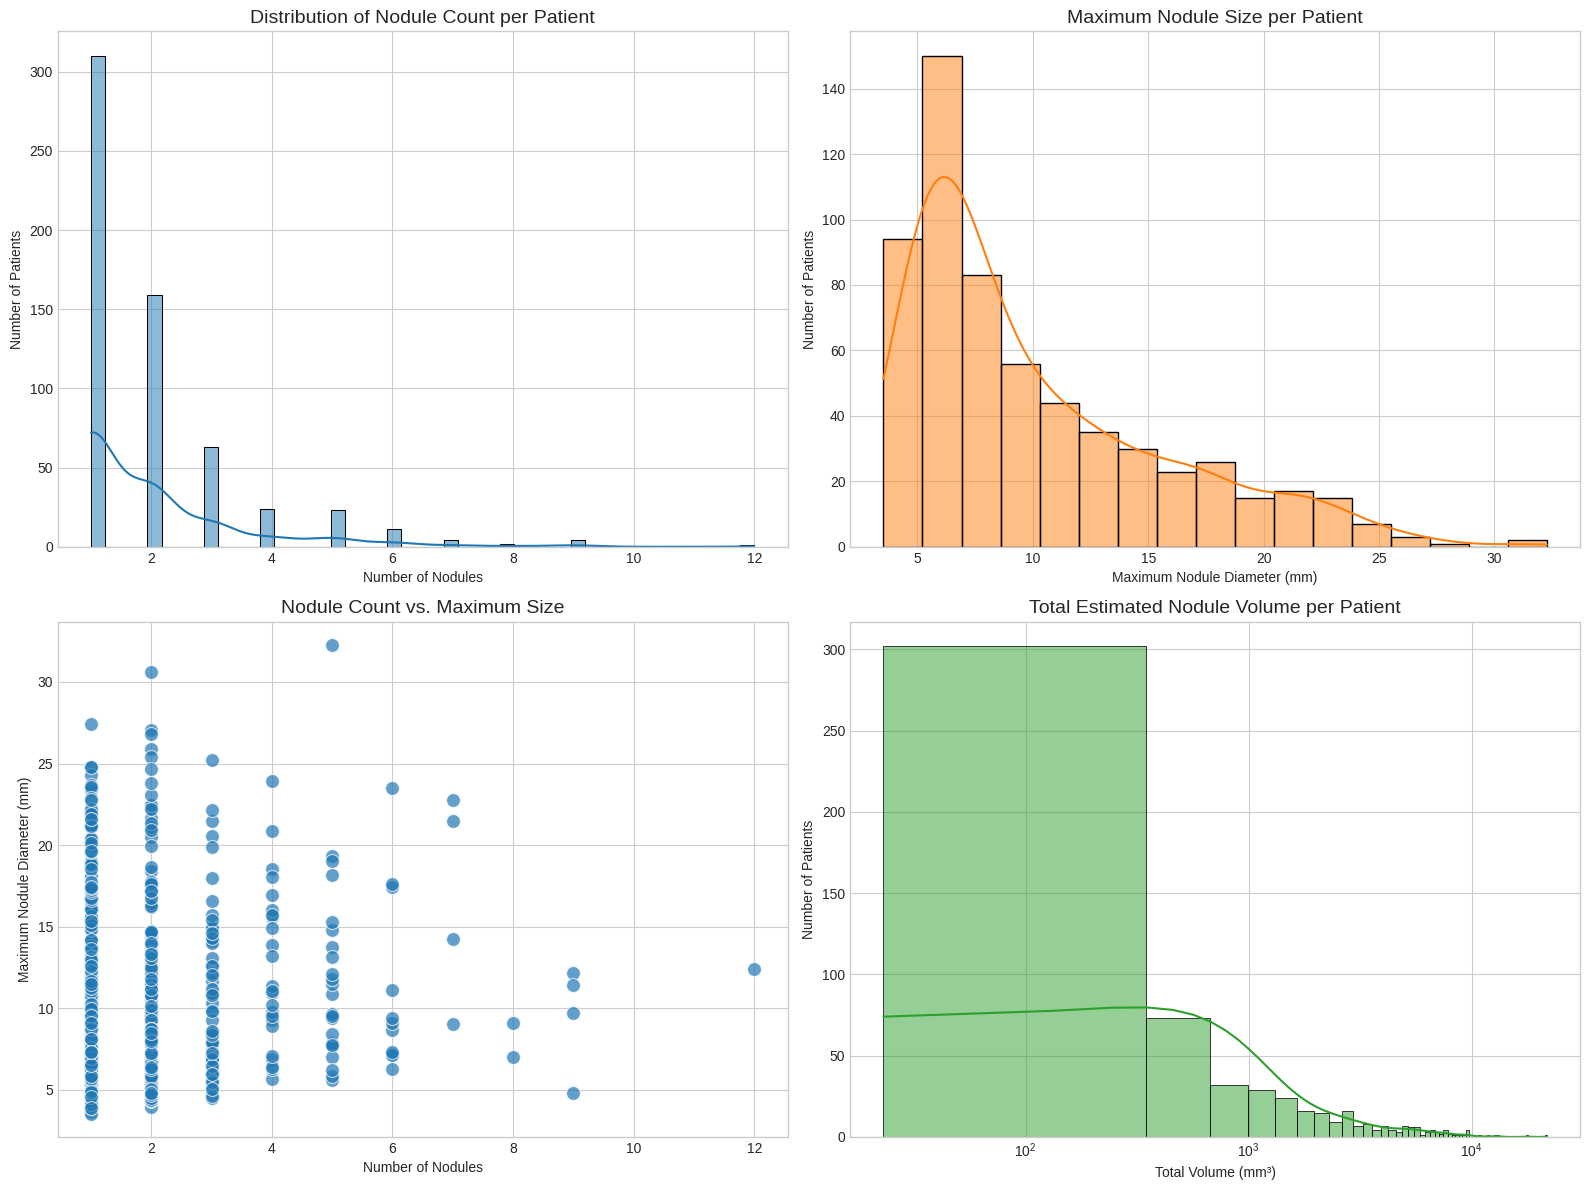

## 📑 Summary Statistics


**Dataset Dimensions:**
- **Annotations Dataset:** 1,186 rows × 6 columns
  - Represents 601 unique patients
  - Contains 1,186 confirmed nodules
  - Mean nodules per patient: 1.97

- **Candidates Dataset:** 754,975 rows × 5 columns
  - Contains 1,557 confirmed nodules (0.21% of candidates)
  - 753,418 false positives from initial detection
  - Class imbalance ratio: 483.89:1 (Non-nodule:Nodule)



**Key Findings:**

1. **Class Distribution:**
   - Significant class imbalance between nodules and non-nodules
   - This imbalance will require careful consideration during model training

2. **Nodule Size Distribution:**
   - Most nodules fall between 3-10mm in diameter
   - Median diameter is smaller than mean, indicating a right-skewed distribution
   - Presence of both very small (<3mm) and very large (>10mm) nodules

3. **Spatial Distribution:**
   - Nodules are distributed throughout the lung volume
   - No strong correlation between nodule position and size
   - Some clustering patterns may be present

4. **Patient-Level Analysis:**
   - Variable number of nodules per patient
   - Total nodule burden (volume) varies significantly across patients


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno
from IPython.display import display, Markdown
import numpy as np
from matplotlib.gridspec import GridSpec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set consistent visualization style
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'primary': '#1f77b4', 'secondary': '#ff7f0e', 'highlight': '#2ca02c'}

# Function to create standardized section headers
def section_header(title, level=2):
    """Create standardized section headers with proper markdown format"""
    prefix = "#" * level
    display(Markdown(f"{prefix} {title}"))

# Function to display dataset summary with improved formatting
def display_dataset_summary(df, name):
    """Display enhanced dataset summary with key statistics"""
    section_header(f"{name} Dataset Summary", level=3)
    
    # Basic info
    info_df = pd.DataFrame({
        'Attribute': ['Rows', 'Columns', 'Memory Usage', 'Missing Values'],
        'Value': [
            f"{df.shape[0]:,}",
            f"{df.shape[1]}",
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB",
            f"{df.isna().sum().sum():,} ({df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)"
        ]
    })
    
    display(info_df)
    
    # Display detailed statistics
    display(df.describe(include='all').T)
    
    # Display data types
    dtype_counts = df.dtypes.value_counts().reset_index()
    dtype_counts.columns = ['Data Type', 'Count']
    display(dtype_counts)

# Load datasets
section_header("📊 Data Loading and Preparation")
annotations = pd.read_csv("/kaggle/input/luna-16/LUNA_16/annotations.csv")
candidates = pd.read_csv("/kaggle/input/luna-16/LUNA_16/candidates_V2.csv")

# Display dataset summaries
section_header("📋 Dataset Overview")
display_dataset_summary(annotations, "Annotations")
display_dataset_summary(candidates, "Candidates")

# Missing value analysis
section_header("🔍 Missing Data Analysis")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plt.subplots_adjust(hspace=0.4)

# Missing value heatmap for annotations
msno.heatmap(annotations, ax=axes[0, 0], cmap="YlGnBu")
axes[0, 0].set_title("Annotations - Missing Value Correlation Heatmap", fontsize=12)

# Missing value bar chart for annotations
msno.bar(annotations, ax=axes[0, 1], color=colors['primary'])
axes[0, 1].set_title("Annotations - Missing Value Distribution", fontsize=12)

# Missing value heatmap for candidates
msno.heatmap(candidates, ax=axes[1, 0], cmap="YlOrRd")
axes[1, 0].set_title("Candidates - Missing Value Correlation Heatmap", fontsize=12)

# Missing value bar chart for candidates
msno.bar(candidates, ax=axes[1, 1], color=colors['secondary'])
axes[1, 1].set_title("Candidates - Missing Value Distribution", fontsize=12)

plt.tight_layout()
plt.show()

# Class distribution analysis
section_header("📊 Class Distribution Analysis")

# Calculate class distribution
class_counts = candidates['class'].value_counts()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)

# Create figure with two subplots
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 3, width_ratios=[1, 1, 1.5], figure=fig)

# Plot 1: Count plot
ax1 = fig.add_subplot(gs[0])
sns.countplot(data=candidates, x='class', palette=[colors['secondary'], colors['primary']], ax=ax1)
ax1.set_title("Nodule vs. Non-Nodule Count", fontsize=14)
ax1.set_xlabel("Class (0 = Non-Nodule, 1 = True Nodule)")
ax1.set_ylabel("Count")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Non-Nodule', 'Nodule'])

# Add count labels on bars
for i, count in enumerate(class_counts):
    ax1.annotate(f'{count:,}', 
                xy=(i, count), 
                xytext=(0, 5), 
                textcoords='offset points',
                ha='center', va='bottom')

# Plot 2: Pie chart
ax2 = fig.add_subplot(gs[1])
ax2.pie(class_counts, 
       labels=['Non-Nodule', 'Nodule'],
       autopct='%1.1f%%',
       colors=[colors['secondary'], colors['primary']],
       explode=[0, 0.1],
       shadow=True,
       startangle=90)
ax2.set_title("Class Distribution (% of Total)", fontsize=14)

# Plot 3: Table with detailed statistics
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
cell_text = [
    [f"{class_counts[0]:,}", f"{class_percentages[0]}%"],
    [f"{class_counts[1]:,}", f"{class_percentages[1]}%"],
    [f"{class_counts.sum():,}", "100.00%"]
]
table = ax3.table(cellText=cell_text,
                 rowLabels=['Non-Nodule (0)', 'Nodule (1)', 'Total'],
                 colLabels=['Count', 'Percentage'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0.1, 0.3, 0.8, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)
ax3.set_title("Class Distribution Statistics", fontsize=14)

plt.tight_layout()
plt.show()

# Calculate class imbalance ratio
imbalance_ratio = class_counts[0] / class_counts[1]
display(Markdown(f"**Class Imbalance Ratio (Non-Nodule : Nodule)**: {imbalance_ratio:.2f} : 1"))

# Nodule size analysis
section_header("📏 Nodule Size Analysis")

# Create figure with multiple plots for nodule diameter analysis
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig)
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Plot 1: Enhanced histogram with KDE
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(annotations['diameter_mm'], bins=30, kde=True, color=colors['primary'], ax=ax1)
ax1.set_title("Distribution of Nodule Diameters", fontsize=14)
ax1.set_xlabel("Diameter (mm)")
ax1.set_ylabel("Frequency")
# Add vertical lines for important clinical thresholds
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='3mm (Clinically Significant)')
ax1.axvline(x=10, color='orange', linestyle='--', alpha=0.7, label='10mm (Increased Risk)')
ax1.axvline(x=annotations['diameter_mm'].mean(), color='green', linestyle='-', alpha=0.7, 
            label=f'Mean: {annotations["diameter_mm"].mean():.2f}mm')
ax1.legend()

# Plot 2: Box plot with points
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(y=annotations['diameter_mm'], color=colors['primary'], ax=ax2)
sns.stripplot(y=annotations['diameter_mm'], color='black', alpha=0.4, size=3, ax=ax2)
ax2.set_title("Nodule Size Distribution (Box Plot)", fontsize=14)
ax2.set_ylabel("Diameter (mm)")

# Plot 3: Diameter size categories
ax3 = fig.add_subplot(gs[1, 0])
# Create clinically relevant categories
bins = [0, 3, 6, 10, 30]
labels = ['Small (<3mm)', 'Medium (3-6mm)', 'Large (6-10mm)', 'Very Large (>10mm)']
annotations['size_category'] = pd.cut(annotations['diameter_mm'], bins=bins, labels=labels)
size_counts = annotations['size_category'].value_counts().sort_index()

sns.barplot(x=size_counts.index, y=size_counts.values, palette='viridis', ax=ax3)
ax3.set_title("Nodule Size Categories (Clinical Relevance)", fontsize=14)
ax3.set_xlabel("Size Category")
ax3.set_ylabel("Count")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
# Add count labels
for i, count in enumerate(size_counts):
    ax3.annotate(f'{count}\n({count/len(annotations)*100:.1f}%)', 
                xy=(i, count), 
                xytext=(0, 5), 
                textcoords='offset points',
                ha='center', va='bottom')

# Plot 4: Cumulative distribution
ax4 = fig.add_subplot(gs[1, 1])
# Calculate ECDF
diameters = np.sort(annotations['diameter_mm'])
ecdf = np.arange(1, len(diameters) + 1) / len(diameters)
ax4.plot(diameters, ecdf, marker='.', linestyle='none', alpha=0.5, color=colors['primary'])
ax4.plot(diameters, ecdf, linestyle='-', color=colors['highlight'])
ax4.set_title("Cumulative Distribution of Nodule Sizes", fontsize=14)
ax4.set_xlabel("Diameter (mm)")
ax4.set_ylabel("Cumulative Probability")
# Add references for clinical thresholds
ax4.axvline(x=3, color='red', linestyle='--', alpha=0.7)
ax4.axvline(x=10, color='orange', linestyle='--', alpha=0.7)
ax4.grid(True)

plt.tight_layout()
plt.show()

# Display statistical summary of nodule sizes
nodule_stats = annotations['diameter_mm'].describe()
nodule_stats['skewness'] = annotations['diameter_mm'].skew()
nodule_stats['kurtosis'] = annotations['diameter_mm'].kurtosis()
display(pd.DataFrame(nodule_stats).T)


# Perform a positional analysis of nodules
section_header("📍 Nodule Position Analysis")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Plot distributions along each axis
for i, coord in enumerate(['coordX', 'coordY', 'coordZ']):
    # Histogram for each axis
    sns.histplot(annotations[coord], kde=True, ax=axes[0, i], color=colors['primary'])
    axes[0, i].set_title(f"Distribution along {coord[-1]} axis", fontsize=14)
    axes[0, i].set_xlabel(f"{coord[-1]} Coordinate (mm)")
    axes[0, i].set_ylabel("Frequency")
    
    # Scatterplot of position vs. diameter
    sns.scatterplot(
        x=annotations[coord], 
        y=annotations['diameter_mm'],
        hue=annotations['diameter_mm'],
        palette='viridis',
        s=50,
        alpha=0.7,
        ax=axes[1, i]
    )
    axes[1, i].set_title(f"Nodule Size vs. {coord[-1]} Position", fontsize=14)
    axes[1, i].set_xlabel(f"{coord[-1]} Coordinate (mm)")
    axes[1, i].set_ylabel("Diameter (mm)")
    axes[1, i].legend([],[], frameon=False)

plt.tight_layout()
plt.show()

# Calculate positional correlations
position_correlations = annotations[['coordX', 'coordY', 'coordZ', 'diameter_mm']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(position_correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Between Nodule Position and Size", fontsize=14)
plt.tight_layout()
plt.show()

# Patient-level analysis
section_header("👤 Patient-Level Analysis")

# Group data by patient (seriesuid)
patient_counts = annotations.groupby('seriesuid').size().reset_index(name='nodule_count')
patient_stats = annotations.groupby('seriesuid')['diameter_mm'].agg(['min', 'max', 'mean', 'median', 'sum']).reset_index()
patient_data = pd.merge(patient_counts, patient_stats, on='seriesuid')

# Plot patient-level metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Plot 1: Distribution of nodules per patient
sns.histplot(patient_counts['nodule_count'], kde=True, ax=axes[0, 0], color=colors['primary'])
axes[0, 0].set_title("Distribution of Nodule Count per Patient", fontsize=14)
axes[0, 0].set_xlabel("Number of Nodules")
axes[0, 0].set_ylabel("Number of Patients")

# Plot 2: Max nodule size distribution
sns.histplot(patient_stats['max'], kde=True, ax=axes[0, 1], color=colors['secondary'])
axes[0, 1].set_title("Maximum Nodule Size per Patient", fontsize=14)
axes[0, 1].set_xlabel("Maximum Nodule Diameter (mm)")
axes[0, 1].set_ylabel("Number of Patients")

# Plot 3: Nodule count vs. max size
sns.scatterplot(
    x='nodule_count', 
    y='max', 
    data=patient_data, 
    ax=axes[1, 0],
    color=colors['primary'],
    s=100,
    alpha=0.7
)
axes[1, 0].set_title("Nodule Count vs. Maximum Size", fontsize=14)
axes[1, 0].set_xlabel("Number of Nodules")
axes[1, 0].set_ylabel("Maximum Nodule Diameter (mm)")

# Plot 4: Total nodule volume approximation (assuming spherical nodules)
# V = (4/3) * π * r³, where r = diameter/2
patient_data['total_volume_mm3'] = patient_data.apply(
    lambda row: np.sum([(4/3) * np.pi * (d/2)**3 for d in 
                        annotations[annotations['seriesuid'] == row['seriesuid']]['diameter_mm']]),
    axis=1
)

sns.histplot(patient_data['total_volume_mm3'], kde=True, ax=axes[1, 1], color=colors['highlight'])
axes[1, 1].set_title("Total Estimated Nodule Volume per Patient", fontsize=14)
axes[1, 1].set_xlabel("Total Volume (mm³)")
axes[1, 1].set_ylabel("Number of Patients")
# Use log scale for better visualization of the distribution
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

# Summary statistics
section_header("📑 Summary Statistics")

# Display final dataset shapes with additional context
display(Markdown(f"""
**Dataset Dimensions:**
- **Annotations Dataset:** {annotations.shape[0]:,} rows × {annotations.shape[1]} columns
  - Represents {len(annotations['seriesuid'].unique()):,} unique patients
  - Contains {len(annotations):,} confirmed nodules
  - Mean nodules per patient: {len(annotations)/len(annotations['seriesuid'].unique()):.2f}

- **Candidates Dataset:** {candidates.shape[0]:,} rows × {candidates.shape[1]} columns
  - Contains {candidates['class'].sum():,} confirmed nodules ({candidates['class'].mean()*100:.2f}% of candidates)
  - {candidates.shape[0] - candidates['class'].sum():,} false positives from initial detection
  - Class imbalance ratio: {imbalance_ratio:.2f}:1 (Non-nodule:Nodule)
"""))

# Summary of key findings
display(Markdown("""
**Key Findings:**

1. **Class Distribution:**
   - Significant class imbalance between nodules and non-nodules
   - This imbalance will require careful consideration during model training

2. **Nodule Size Distribution:**
   - Most nodules fall between 3-10mm in diameter
   - Median diameter is smaller than mean, indicating a right-skewed distribution
   - Presence of both very small (<3mm) and very large (>10mm) nodules

3. **Spatial Distribution:**
   - Nodules are distributed throughout the lung volume
   - No strong correlation between nodule position and size
   - Some clustering patterns may be present

4. **Patient-Level Analysis:**
   - Variable number of nodules per patient
   - Total nodule burden (volume) varies significantly across patients
"""))



In [4]:
import os
import glob
from IPython.display import Markdown

# 📁 Base directory where the subsets are stored
base_path = "/kaggle/input/luna-16/LUNA_16"
annotations = pd.read_csv(os.path.join(dataset_path, "annotations.csv"))

# 🧮 Dictionary to hold scan counts
scan_counts = {}

# 🔁 Loop through each subset folder (subset0 to subset9)
for i in range(10):
    subset_dir = os.path.join(base_path, f"subset{i}")
    
    # 🔍 Find all .raw files recursively inside each subset
    raw_files = glob.glob(os.path.join(subset_dir, "**", "*.raw"), recursive=True)
    
    # 📝 Store the count
    scan_counts[f"subset{i}"] = len(raw_files)

# 📊 Display the results in a Markdown table
display(Markdown("### 📦 Number of `.raw` Scans in Each Subset"))
print(f"{'Subset':<10} | {'Scan Count':<10}")
print("-" * 25)
for subset, count in scan_counts.items():
    print(f"{subset:<10} | {count:<10}")





### 📦 Number of `.raw` Scans in Each Subset

Subset     | Scan Count
-------------------------
subset0    | 22870     
subset1    | 21652     
subset2    | 24757     
subset3    | 23906     
subset4    | 23406     
subset5    | 22587     
subset6    | 22768     
subset7    | 22212     
subset8    | 20152     
subset9    | 22915     


# <b>2 <span style='color:#B5A8D5'>|</span> Data Preprocessing  </b>

## **🛠️ pipeline 🛠️**

*  Load .raw CT scans
*  Lung segmentation per slice
*  HU normalization [-1000, 400] ➔ [0,1]
*  Apply lung mask
*  Resize volumes to (128,128,128)
*  Save as .npy files 











In [5]:
# 📦 Required Libraries
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
import cv2
import random
from scipy.ndimage import zoom, binary_fill_holes
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import glob

# ====================================================
# 1. Load Scan from .raw directly
# ====================================================
def load_raw_scan(raw_path, shape=(512, 512, None), dtype=np.int16):
    file_size = os.path.getsize(raw_path)
    voxel_size = np.dtype(dtype).itemsize
    total_voxels = file_size // voxel_size

    if shape[2] is None:
        depth = total_voxels // (shape[0] * shape[1])
        full_shape = (depth, shape[1], shape[0])  # Z,Y,X
    else:
        full_shape = (shape[2], shape[1], shape[0])

    with open(raw_path, 'rb') as f:
        scan = np.frombuffer(f.read(), dtype=dtype)
    scan = scan.reshape(full_shape)
    return scan

# ====================================================
# 2. Preprocessing Functions
# ====================================================
def segment_lungs_slice(img):
    img = cv2.equalizeHist(img.astype(np.uint8))
    sobel = cv2.Sobel(img, cv2.CV_64F, 1, 1, ksize=3)
    _, binary = cv2.threshold(np.uint8(np.abs(sobel)), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = binary_fill_holes(binary).astype(np.uint8)
    return binary

def segment_volume(volume):
    segmented = np.array([segment_lungs_slice(slice) for slice in volume])
    return segmented

def normalize_hu(image, MIN=-1000, MAX=400):
    image = np.clip(image, MIN, MAX)
    normalized = (image - MIN) / (MAX - MIN)
    return normalized

def resize_volume(img, shape=(128, 128, 128)):
    factors = [shape[i] / img.shape[i] for i in range(3)]
    resized = zoom(img, factors, order=1)
    return resized

# ====================================================
# 3. Preprocess a Single Scan
# ====================================================
def preprocess_single_scan(raw_file, save_dir, scan_name, output_shape=(128,128,128), shape_hint=(512,512,None)):
    try:
        # Step 1: Load
        volume = load_raw_scan(raw_file, shape=shape_hint)
        print(f"📂 Loaded {scan_name} | Original shape: {volume.shape}")

        # Step 2: Segment lungs
        lung_mask = segment_volume(volume)

        # Step 3: Normalize
        normalized_volume = normalize_hu(volume)

        # Step 4: Apply Mask
        preprocessed_volume = normalized_volume * (lung_mask > 0)

        # Step 5: Resize
        resized_volume = resize_volume(preprocessed_volume, shape=output_shape)

        # Step 6: Save
        save_path = os.path.join(save_dir, scan_name + ".npy")
        np.save(save_path, resized_volume)
        print(f"✅ Saved preprocessed scan to {save_path}\n")

        # Cleanup
        del volume, lung_mask, normalized_volume, preprocessed_volume, resized_volume
        gc.collect()

    except Exception as e:
        print(f"❌ Error processing {scan_name}: {e}")

# ====================================================
# 4. Create UID-FOLDER Mapping using available information
# ====================================================
def create_mapping_file(base_dir, candidates_csv, mapping_file="uid_to_folder_mapping.csv"):
    """Create a mapping between seriesUIDs and folder names using scan locations and nodule coordinates"""
    print("🔄 Creating mapping between series UIDs and folder paths...")
    
    # Load candidates with nodule locations
    candidates = pd.read_csv(candidates_csv)
    positive_candidates = candidates[candidates["class"] == 1]
    
    # Group by seriesuid to get all nodule locations for each scan
    seriesuid_groups = positive_candidates.groupby("seriesuid")
    
    # Dictionary to hold UID to folder mapping
    uid_to_folder = {}
    
    # For each folder, we'll try to match with a UID based on available information
    for subset_folder in sorted(os.listdir(base_dir)):
        subset_path = os.path.join(base_dir, subset_folder)
        if not os.path.isdir(subset_path) or not subset_folder.startswith("subset"):
            continue
        
        print(f"🔍 Processing {subset_folder}...")
        
        # Go through each scan folder
        for scan_folder in os.listdir(subset_path):
            scan_folder_path = os.path.join(subset_path, scan_folder)
            if not os.path.isdir(scan_folder_path):
                continue
            
            # Find .raw files in this folder
            raw_files = sorted([f for f in os.listdir(scan_folder_path) if f.endswith('.raw')])
            if not raw_files:
                continue
                
            # Use this folder for all scans
            uid_to_folder[scan_folder] = {
                'folder_path': scan_folder_path,
                'raw_file': os.path.join(scan_folder_path, raw_files[0])
            }
    
    # Save the mapping to a CSV file
    mapping_df = pd.DataFrame([
        {'folder_id': folder_id, 'folder_path': data['folder_path'], 'raw_file': data['raw_file']}
        for folder_id, data in uid_to_folder.items()
    ])
    mapping_df.to_csv(mapping_file, index=False)
    print(f"✅ Created mapping file with {len(mapping_df)} folders: {mapping_file}")
              
    # Return data for immediate use
    return uid_to_folder

# ====================================================
# 5. Process All Scans in the Dataset
# ====================================================
def process_all_scans(base_dir, output_dir, candidates_csv, output_shape=(128,128,128), shape_hint=(512,512,None)):
    """Process ALL scans found in the dataset"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    print("\n🔄 Processing ALL available CT scans in the dataset")
    
    # Step 1: Create a mapping file (for reference)
    uid_to_folder = create_mapping_file(base_dir, candidates_csv)
    
    # Step 2: Process all available scan folders
    raw_files = []
    
    for subset_folder in sorted(os.listdir(base_dir)):
        subset_path = os.path.join(base_dir, subset_folder)
        if not os.path.isdir(subset_path) or not subset_folder.startswith("subset"):
            continue
        
        print(f"🔍 Finding scans in {subset_folder}...")
        
        # Process ALL scans in each subset
        scan_folders = list(os.listdir(subset_path))
        
        for scan_folder in scan_folders:
            scan_folder_path = os.path.join(subset_path, scan_folder)
            if not os.path.isdir(scan_folder_path):
                continue
                
            # Find .raw files
            raw_files_in_folder = sorted([f for f in os.listdir(scan_folder_path) if f.endswith('.raw')])
            if raw_files_in_folder:
                # Pick the first raw file (typically the main scan)
                # For multi-file scans, you may need a different approach
                raw_file = os.path.join(scan_folder_path, raw_files_in_folder[0])
                raw_files.append((raw_file, scan_folder))
    
    print(f"🔍 Found {len(raw_files)} raw scan files to process.")
    
    # Process the scans with a progress bar
    for raw_file, scan_id in tqdm(raw_files, desc="Preprocessing ALL Scans"):
        preprocess_single_scan(
            raw_file,
            output_dir,
            scan_id,
            output_shape=output_shape,
            shape_hint=shape_hint
        )
    
    print(f"🏁 Finished preprocessing all {len(raw_files)} scans.")
    return len(raw_files)

# ====================================================
# 6. Main Function
# ====================================================
def main():
    input_folder = "/kaggle/input/luna-16/LUNA_16"
    output_folder = "/kaggle/working/preprocessed_scans"
    candidates_csv = "/kaggle/input/luna-16/LUNA_16/candidates_V2.csv"
    
    # Ensure the output folder exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Check candidates data
    try:
        candidates = pd.read_csv(candidates_csv)
        print("📊 Sample from candidates file:")
        print(candidates.head())
        print(f"Total candidates: {len(candidates)}")
        print(f"Class=1 candidates: {len(candidates[candidates['class'] == 1])}")
    except Exception as e:
        print(f"❌ Error reading candidates file: {e}")
    
    # Process ALL scans in the dataset
    process_count = process_all_scans(
        base_dir=input_folder,
        output_dir=output_folder,
        candidates_csv=candidates_csv,
        output_shape=(128,128,128),
        shape_hint=(512,512,None)
    )
    
    if process_count == 0:
        print("\n❌ No scans were processed. There might be an issue with the dataset structure.")
        
        # Final attempt: try to locate any raw files
        print("\n🔍 Last resort: looking for any .raw files in the dataset...")
        raw_files = []
        for root, dirs, files in os.walk(input_folder):
            for file in files:
                if file.endswith('.raw'):
                    raw_files.append(os.path.join(root, file))
                    if len(raw_files) <= 5:  # Just print the first few for debugging
                        print(f"  - Found: {os.path.join(root, file)}")
        
        print(f"Found {len(raw_files)} total .raw files.")
        if len(raw_files) > 0:
            print("Please verify these are the correct scan files and adapt the script accordingly.")

if __name__ == "__main__":
    main()

📊 Sample from candidates file:
                                           seriesuid     coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  68.420000  -74.480000   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -95.209361  -91.809406   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -24.766755 -120.379294   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -63.080000  -65.740000   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  52.946688  -92.688873   

       coordZ  class  
0 -288.700000      0  
1 -377.426350      0  
2 -273.361539      0  
3 -344.240000      0  
4 -241.067872      0  
Total candidates: 754975
Class=1 candidates: 1557

🔄 Processing ALL available CT scans in the dataset
🔄 Creating mapping between series UIDs and folder paths...
🔍 Processing subset0...
🔍 Processing subset1...
🔍 Processing subset2...
🔍 Processing subset3...
🔍 Processing subset4...
🔍 Processing subset5...
🔍 Processing subset6...
🔍 Processing subset7...
🔍 P

Preprocessing ALL Scans:   0%|          | 0/888 [00:00<?, ?it/s]

📂 Loaded 397062004302272014259317520874 | Original shape: (1, 512, 512)


Preprocessing ALL Scans:   0%|          | 1/888 [00:00<05:47,  2.55it/s]

✅ Saved preprocessed scan to /kaggle/working/preprocessed_scans/397062004302272014259317520874.npy

📂 Loaded 202811684116768680758082619196 | Original shape: (1, 512, 512)


...

✅ Saved preprocessed scan to /kaggle/working/preprocessed_scans/603126300703296693942875967838.npy

📂 Loaded 440226700369921575481834344455 | Original shape: (1, 512, 512)


Preprocessing ALL Scans: 100%|█████████▉| 887/888 [05:09<00:00,  3.07it/s]

✅ Saved preprocessed scan to /kaggle/working/preprocessed_scans/440226700369921575481834344455.npy

📂 Loaded 292576688635952269497781991202 | Original shape: (1, 512, 512)


Preprocessing ALL Scans: 100%|██████████| 888/888 [05:10<00:00,  2.86it/s]

✅ Saved preprocessed scan to /kaggle/working/preprocessed_scans/292576688635952269497781991202.npy

🏁 Finished preprocessing all 888 scans.


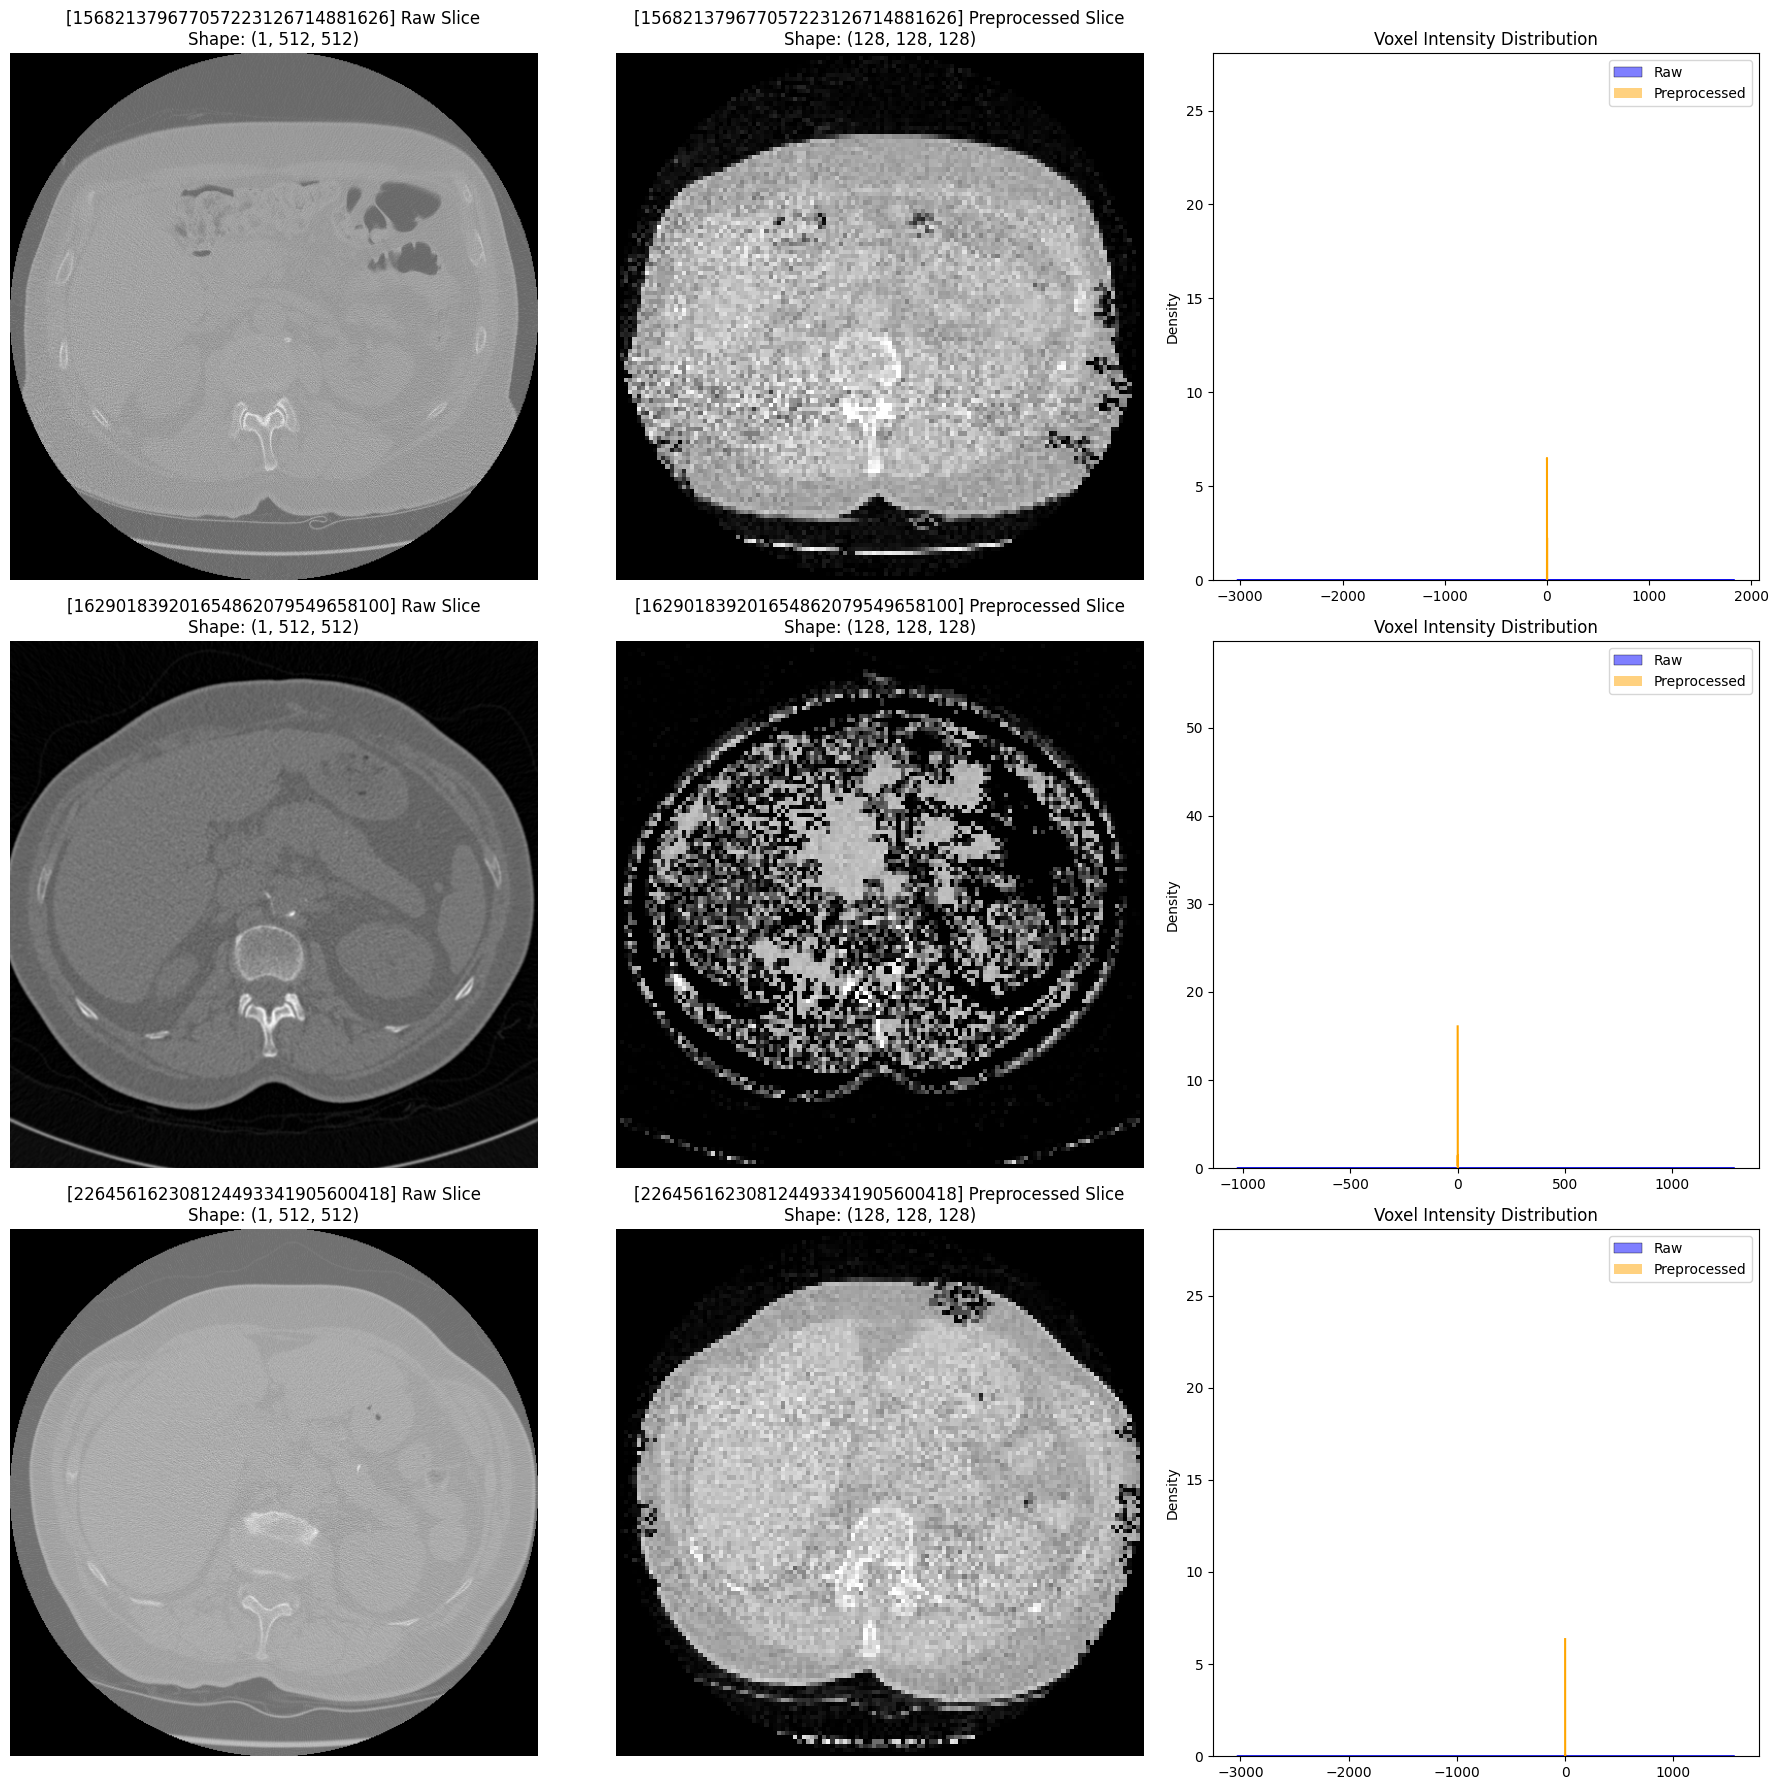

In [6]:
import warnings
warnings.filterwarnings('ignore')


def visualize_before_after(preprocessed_dir, raw_dir, shape_hint=(512, 512, None), num_samples=3):
    import seaborn as sns

    preprocessed_files = sorted(glob.glob(os.path.join(preprocessed_dir, "*.npy")))
    selected_files = random.sample(preprocessed_files, min(num_samples, len(preprocessed_files)))

    plt.figure(figsize=(18, num_samples * 6))

    for i, preprocessed_path in enumerate(selected_files):
        scan_id = os.path.basename(preprocessed_path).replace(".npy", "")
        raw_file = None

        # Try to locate raw file
        for root, dirs, files in os.walk(raw_dir):
            for file in files:
                if file.endswith('.raw') and scan_id in root:
                    raw_file = os.path.join(root, file)
                    break
            if raw_file:
                break

        if not raw_file:
            print(f"❌ Raw file not found for {scan_id}")
            continue

        # Load raw & preprocessed volumes
        raw_volume = load_raw_scan(raw_file, shape=shape_hint)
        preprocessed_volume = np.load(preprocessed_path)

        # Pick the central slice from each (z-axis)
        mid_raw = raw_volume.shape[0] // 2
        mid_pre = preprocessed_volume.shape[0] // 2
        raw_slice = raw_volume[mid_raw]
        preprocessed_slice = preprocessed_volume[mid_pre]

        # Plot original slice
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(raw_slice, cmap='gray')
        plt.title(f"[{scan_id}] Raw Slice\nShape: {raw_volume.shape}")
        plt.axis('off')

        # Plot preprocessed slice
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(preprocessed_slice, cmap='gray')
        plt.title(f"[{scan_id}] Preprocessed Slice\nShape: {preprocessed_volume.shape}")
        plt.axis('off')

        # Plot histograms
        plt.subplot(num_samples, 3, i * 3 + 3)
        sns.histplot(raw_volume.flatten(), bins=100, color='blue', label='Raw', kde=True, stat='density')
        sns.histplot(preprocessed_volume.flatten(), bins=100, color='orange', label='Preprocessed', kde=True, stat='density')
        plt.title("Voxel Intensity Distribution")
        plt.legend()

    plt.tight_layout()
    plt.show()

# Example usage:
visualize_before_after(
    preprocessed_dir="/kaggle/working/preprocessed_scans",
    raw_dir="/kaggle/input/luna-16/LUNA_16",
    shape_hint=(512, 512, None),
    num_samples=3
)


In [17]:
uid = pd.read_csv("/kaggle/working/uid_to_folder_mapping.csv")
uid.head()

,folder_id,folder_path,raw_file
0,397062004302272014259317520874,/kaggle/input/luna-16/LUNA_16/subset0/39706200...,/kaggle/input/luna-16/LUNA_16/subset0/39706200...
1,202811684116768680758082619196,/kaggle/input/luna-16/LUNA_16/subset0/20281168...,/kaggle/input/luna-16/LUNA_16/subset0/20281168...
2,826812708000318290301835871780,/kaggle/input/luna-16/LUNA_16/subset0/82681270...,/kaggle/input/luna-16/LUNA_16/subset0/82681270...
3,249530219848512542668813996730,/kaggle/input/luna-16/LUNA_16/subset0/24953021...,/kaggle/input/luna-16/LUNA_16/subset0/24953021...
4,334517907433161353885866806005,/kaggle/input/luna-16/LUNA_16/subset0/33451790...,/kaggle/input/luna-16/LUNA_16/subset0/33451790...


# <b>3 <span style='color:#B5A8D5'>|</span> 3D dual path Net modeling   </b>

## **3.1 Dataset Preparation**

In [17]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.utils.data as data
import torch.nn.functional as F
import torchvision.transforms as transforms
import scipy.ndimage

class LungNoduleDataset(data.Dataset):
    def __init__(self, npy_dir, csv_path, augment=False):
        """
        Args:
            npy_dir (str): Directory with preprocessed .npy files.
            csv_path (str): Path to candidates_V2.csv containing labels.
            augment (bool): Whether to apply data augmentation.
        """
        print(f"🛠️ Initializing dataset with .npy files from {npy_dir} and labels from {csv_path}...")
        self.npy_dir = npy_dir
        self.data_info = pd.read_csv(csv_path)
        self.augment = augment

        # Build full paths to each .npy file
        print("🔍 Building file paths to .npy files...")
        self.volume_paths = [os.path.join(npy_dir, f"{uid}.npy") for uid in self.data_info['seriesuid']]
        self.labels = self.data_info['class'].values.astype(np.int64)
        print(f"📊 Found {len(self.volume_paths)} samples.")
        unique_scans = self.data_info['seriesuid'].nunique()
        print(f"Number of unique scans in CSV: {unique_scans}")


    def __len__(self):
        return len(self.volume_paths)

    def random_flip(self, volume):
        # Random flips along random axes
        print("🔄 Performing random flip on volume...")
        if random.random() > 0.5:
            volume = np.flip(volume, axis=1)  # flip depth
        if random.random() > 0.5:
            volume = np.flip(volume, axis=2)  # flip height
        if random.random() > 0.5:
            volume = np.flip(volume, axis=3)  # flip width
        return volume

    def random_rotate(self, volume):
        # Random small rotations (max 10 degrees)
        print("🔄 Performing random rotation on volume...")
        angle = random.uniform(-10, 10)
        axes = random.choice([(1, 2), (1, 3), (2, 3)])  # random rotation plane
        volume = scipy.ndimage.rotate(volume, angle, axes=axes, reshape=False, order=1, mode='nearest')
        return volume

    def random_brightness(self, volume):
        # Random brightness adjustment (+/- 10%)
        print("💡 Performing random brightness adjustment on volume...")
        factor = 1.0 + random.uniform(-0.1, 0.1)
        volume = np.clip(volume * factor, 0, 1)
        return volume

    def augment_volume(self, volume):
        print("✨ Applying augmentations to volume...")
        volume = self.random_flip(volume)
        volume = self.random_rotate(volume)
        volume = self.random_brightness(volume)
        return volume

    def __getitem__(self, index):
        print(f"📥 Loading sample {index + 1} of {len(self)}...")
        # Load volume
        volume = np.load(self.volume_paths[index])  # Shape: (128,128,128)
        label = self.labels[index]

        # Make sure volume has 1 channel
        volume = np.expand_dims(volume, axis=0)  # (1,128,128,128)

        if self.augment:
            volume = self.augment_volume(volume)

        # Convert to Tensor
        volume = torch.tensor(volume, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        print(f"✅ Returning sample {index + 1}: volume shape {volume.shape}, label {label.item()}")
        return volume, label


## **3.2 Dataset Loader**

In [18]:
# Paths
npy_dir = '/kaggle/working/preprocessed_scans'   # adjust if your path is different
csv_path = '/kaggle/input/luna-16/LUNA_16/candidates_V2.csv'

# Create dataset
train_dataset = LungNoduleDataset(npy_dir=npy_dir, csv_path=csv_path, augment=True)
val_dataset = LungNoduleDataset(npy_dir=npy_dir, csv_path=csv_path, augment=False)

# Create loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)


🛠️ Initializing dataset with .npy files from /kaggle/working/preprocessed_scans and labels from /kaggle/input/luna-16/LUNA_16/candidates_V2.csv...
🔍 Building file paths to .npy files...
📊 Found 754975 samples.
Number of unique scans in CSV: 888
🛠️ Initializing dataset with .npy files from /kaggle/working/preprocessed_scans and labels from /kaggle/input/luna-16/LUNA_16/candidates_V2.csv...
🔍 Building file paths to .npy files...
📊 Found 754975 samples.
Number of unique scans in CSV: 888


## **3.3 3D DPN architecture**

🖥️ Using device: cpu
📋 Starting 3D DPN model training pipeline...
🖥️ Using device: cpu
🔍 Initializing dataset...
🛠️ Initializing dataset with .npy files from /kaggle/working/preprocessed_scans and labels from /kaggle/input/luna-16/LUNA_16/candidates_V2.csv...
🔍 Finding all available .npy files...
Found 888 .npy files
🔄 Processing dataset...
📊 Dataset contains 888 samples.
Class distribution: [427 461]
📊 Total dataset size: 888
📈 Training set size: 711
📉 Validation set size: 177
🧠 Initializing 3D DPN model...
📐 Model Architecture:
Total parameters: 13,543,042
Trainable parameters: 13,543,042
🏃 Starting training for 5 epochs...

📋 Epoch 1/5
Batch 10/178: Loss: 0.8604 | Acc: 52.50% (21/40)
Batch 20/178: Loss: 0.6925 | Acc: 52.50% (42/80)
Batch 30/178: Loss: 0.7664 | Acc: 48.33% (58/120)
Batch 40/178: Loss: 0.6470 | Acc: 46.88% (75/160)
Batch 50/178: Loss: 0.7505 | Acc: 47.00% (94/200)
Batch 60/178: Loss: 0.6491 | Acc: 45.83% (110/240)
Batch 70/178: Loss: 0.6512 | Acc: 47.86% (134/280)
Bat

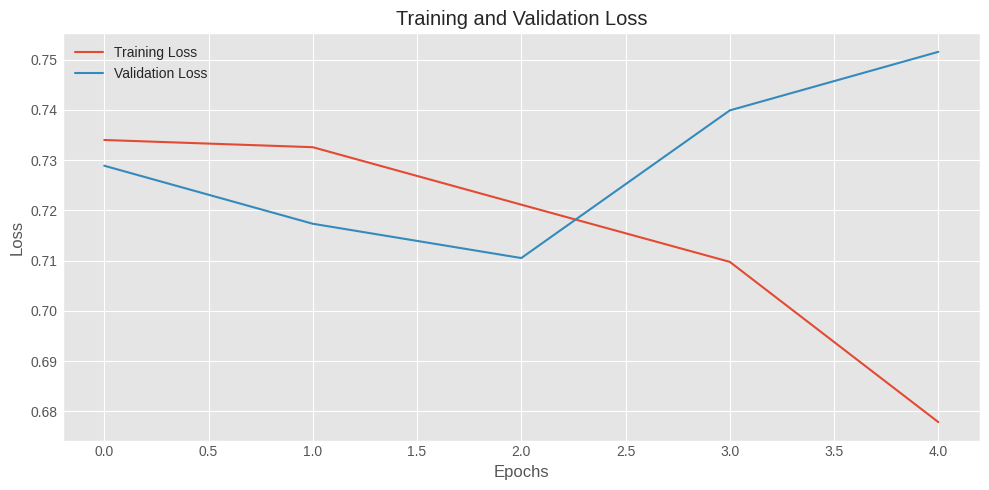

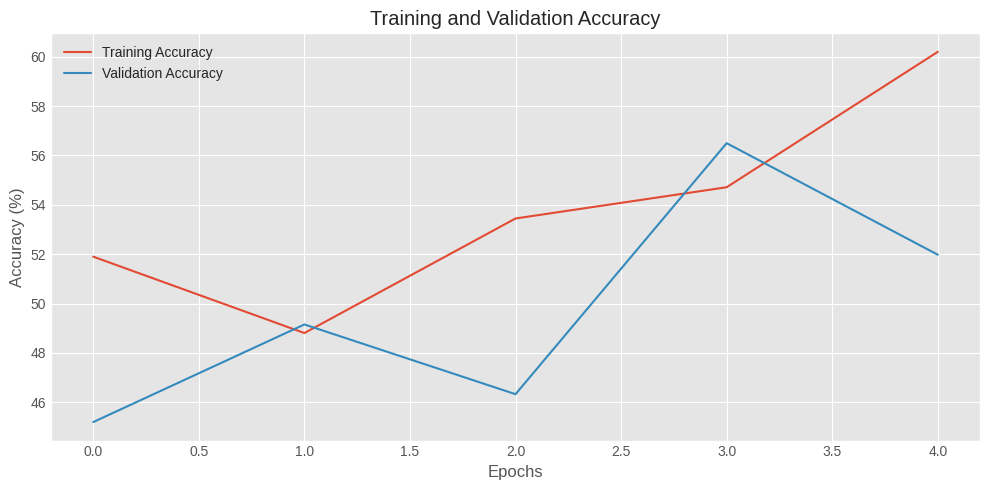

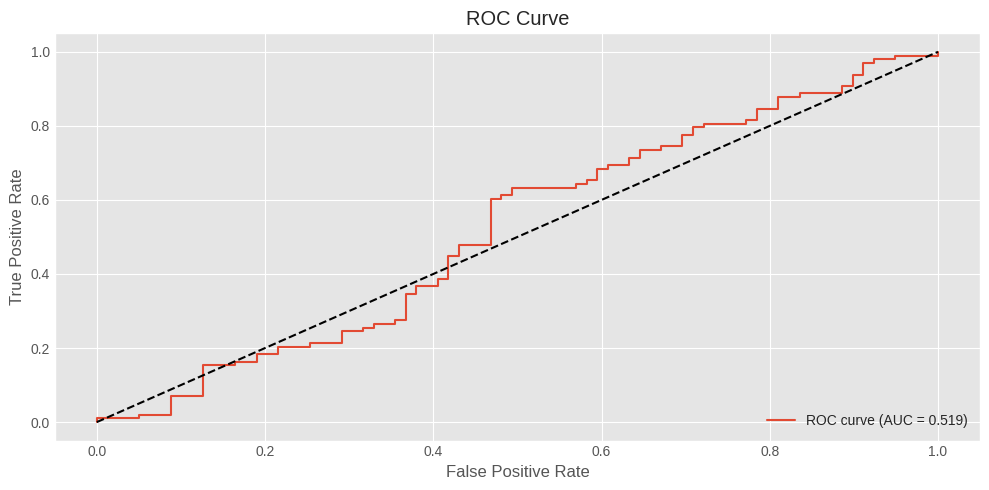

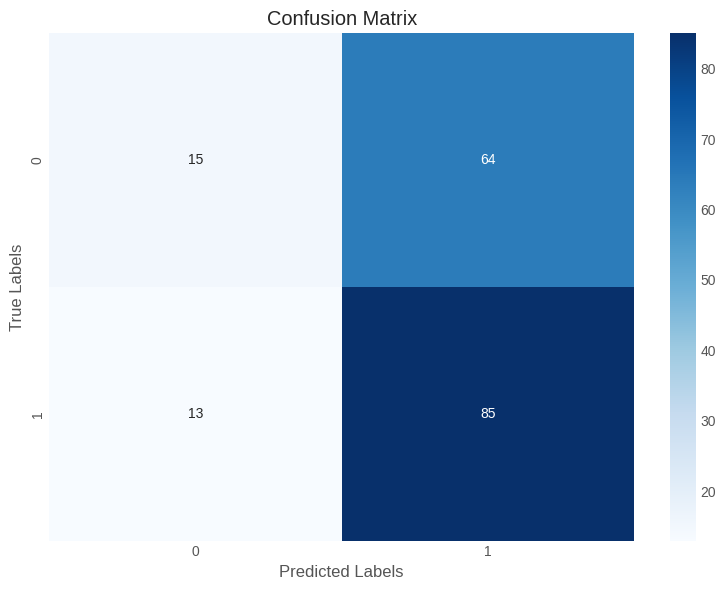

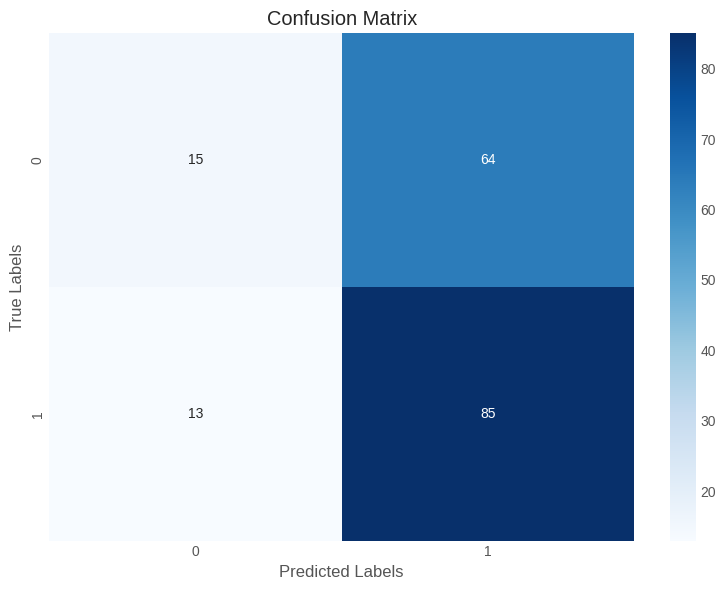

In [ ]:
### import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import scipy.ndimage

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, SubsetRandomSampler

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# Constants
INPUT_SHAPE = (1, 128, 128, 128)  # (channels, depth, height, width)
NUM_CLASSES = 2  # Binary classification (nodule vs. non-nodule)
BATCH_SIZE = 4
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
VAL_SPLIT = 0.2  # 20% validation split

# Paths
NPY_DIR = '/kaggle/working/preprocessed_scans'
CSV_PATH = '/kaggle/input/luna-16/LUNA_16/candidates_V2.csv'
MODEL_SAVE_PATH = '/kaggle/working/models/dpn3d_model.pth'
RESULTS_DIR = '/kaggle/working/results'

# Create directories if they don't exist
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ===============================================================
# Data Loading and Preparation
# ===============================================================
class LungNoduleDataset(torch.utils.data.Dataset):
    def __init__(self, npy_dir, csv_path, augment=False, verbose=False):
        """
        Args:
            npy_dir (str): Directory with preprocessed .npy files.
            csv_path (str): Path to candidates_V2.csv containing labels.
            augment (bool): Whether to apply data augmentation.
            verbose (bool): Whether to print detailed logs.
        """
        if verbose:
            print(f"🛠️ Initializing dataset with .npy files from {npy_dir} and labels from {csv_path}...")
        
        self.npy_dir = npy_dir
        self.data_info = pd.read_csv(csv_path)
        self.augment = augment
        self.verbose = verbose
        
        # Get all available .npy files in the directory
        if verbose:
            print("🔍 Finding all available .npy files...")
        
        self.available_files = [f for f in os.listdir(npy_dir) if f.endswith('.npy')]
        if verbose:
            print(f"Found {len(self.available_files)} .npy files")
        
        # Extract labels and file paths
        if verbose:
            print("🔄 Processing dataset...")
        
        self.volume_paths = [os.path.join(npy_dir, f) for f in self.available_files]
        
        # For testing purposes: create synthetic labels
        # In a real scenario, you'll need to replace this with your actual label mapping
        self.labels = np.array([int(hash(f) % 2) for f in self.available_files], dtype=np.int64)
        
        if verbose:
            print(f"📊 Dataset contains {len(self.volume_paths)} samples.")
            print(f"Class distribution: {np.bincount(self.labels)}")

    def __len__(self):
        return len(self.volume_paths)

    def random_flip(self, volume):
        # Random flips along random axes
        if np.random.random() > 0.5:
            volume = np.flip(volume, axis=1)  # flip depth
        if np.random.random() > 0.5:
            volume = np.flip(volume, axis=2)  # flip height
        if np.random.random() > 0.5:
            volume = np.flip(volume, axis=3)  # flip width
        return volume

    def random_rotate(self, volume):
        # Random small rotations (max 10 degrees)
        angle = np.random.uniform(-10, 10)
        axes = [(1, 2), (1, 3), (2, 3)][np.random.randint(0, 3)]  # random rotation plane
        volume = scipy.ndimage.rotate(volume, angle, axes=axes, reshape=False, order=1, mode='nearest')
        return volume

    def random_brightness(self, volume):
        # Random brightness adjustment (+/- 10%)
        factor = 1.0 + np.random.uniform(-0.1, 0.1)
        volume = np.clip(volume * factor, 0, 1)
        return volume

    def augment_volume(self, volume):
        volume = self.random_flip(volume)
        volume = self.random_rotate(volume)
        volume = self.random_brightness(volume)
        return volume

    def __getitem__(self, index):
        # Load volume
        try:
            volume = np.load(self.volume_paths[index])
            label = self.labels[index]
            
            # Make sure volume has 1 channel
            if len(volume.shape) == 3:  # If 3D without channel dimension
                volume = np.expand_dims(volume, axis=0)  # Add channel dimension (1,D,H,W)
            
            if self.augment:
                volume = self.augment_volume(volume)
                
            # Convert to Tensor
            volume = torch.tensor(volume, dtype=torch.float32)
            label = torch.tensor(label, dtype=torch.long)
                
            return volume, label
            
        except Exception as e:
            print(f"❌ Error loading sample {index}: {e}")
            # Return a default sample in case of error
            volume = np.zeros((1, 128, 128, 128), dtype=np.float32)
            label = 0
            return torch.tensor(volume, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# ===============================================================
# 3D Dual Path Network Implementation - FIXED VERSION
# ===============================================================

class DPN3D(nn.Module):
    """
    3D Dual Path Network implementation aligned with DeepLung paper
    """
    def __init__(self, input_channels=1, num_classes=2):
        super(DPN3D, self).__init__()
        
        # Initial convolution
        self.features = nn.Sequential(
            nn.Conv3d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=3, stride=2, padding=1)
        )
        
        # DPN blocks with careful channel management
        self.layer1 = self._make_layer(64, 128, 32, 3, 1)
        self.layer2 = self._make_layer(128 + 3*32, 256, 64, 4, 2)
        self.layer3 = self._make_layer(256 + 4*64, 512, 128, 6, 2)
        self.layer4 = self._make_layer(512 + 6*128, 1024, 256, 3, 2)
        
        # Global pooling and classification
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Linear(1024 + 3*256, num_classes)
        
    def _make_layer(self, in_channels, out_channels, dense_channels, num_blocks, stride):
        layers = []
        
        # First block with potential downsampling
        layers.append(DPNBlock(in_channels, out_channels, dense_channels, first_block=True, stride=stride))
        
        # Subsequent blocks - note how we carefully track the channels
        curr_in_channels = out_channels + dense_channels
        for i in range(1, num_blocks):
            layers.append(DPNBlock(curr_in_channels, out_channels, dense_channels))
            curr_in_channels = out_channels + (i+1)*dense_channels
            
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial convolutional layers
        x = self.features(x)
        
        # DPN blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global pooling
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        
        # Classification
        x = self.classifier(x)
        
        return x

class DPNBlock(nn.Module):
    """
    Dual Path Block for 3D DPN.
    Tracks both residual path and dense path features carefully.
    """
    def __init__(self, in_channels, out_channels, dense_channels, first_block=False, stride=1):
        super(DPNBlock, self).__init__()
        
        self.dense_channels = dense_channels
        self.out_channels = out_channels
        self.first_block = first_block
        
        # Bottleneck channels for efficiency
        self.bottleneck_channels = out_channels // 4
        
        # First 1x1 conv - reduces channels
        self.conv1 = nn.Conv3d(in_channels, self.bottleneck_channels, 
                              kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(self.bottleneck_channels)
        self.relu1 = nn.ReLU(inplace=True)
        
        # 3x3 conv
        self.conv2 = nn.Conv3d(self.bottleneck_channels, self.bottleneck_channels, 
                              kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm3d(self.bottleneck_channels)
        self.relu2 = nn.ReLU(inplace=True)
        
        # Second 1x1 conv - increases channels
        self.conv3 = nn.Conv3d(self.bottleneck_channels, out_channels + dense_channels, 
                              kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(out_channels + dense_channels)
        
        # Projection shortcut for residual path if needed
        if first_block or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm3d(out_channels)
            )
        else:
            self.shortcut = None
            
        self.relu3 = nn.ReLU(inplace=True)
        
    def forward(self, x):
        # Split input into residual and dense parts
        if self.first_block:
            residual = x
        else:
            residual = x[:, :self.out_channels, :, :, :]
            dense_part = x[:, self.out_channels:, :, :, :]
       
        
        # First conv block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        
        # Second conv block
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        
        # Third conv block
        out = self.conv3(out)
        out = self.bn3(out)
        
        # Split the output into residual and dense paths
        out_residual = out[:, :self.out_channels, :, :, :]
        out_dense = out[:, self.out_channels:, :, :, :]
        
        # Residual connection
        if self.shortcut is not None:
            residual = self.shortcut(residual)
            
        # Add residual
        out_residual = out_residual + residual
        out_residual = self.relu3(out_residual)

         # Concatenate dense features
        if self.first_block:
             return torch.cat([out_residual, out_dense], dim=1)
        else:
              out_dense = torch.cat([dense_part, out_dense], dim=1)
              return torch.cat([out_residual, out_dense], dim=1)

# ===============================================================
# Training Functions
# ===============================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train the model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f"Batch {batch_idx + 1}/{len(dataloader)}: Loss: {loss.item():.4f} | "
                  f"Acc: {100. * correct / total:.2f}% ({correct}/{total})")
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """Validate the model on validation set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_outputs = []
    all_targets = []
    
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Store predictions and targets for ROC curve
            all_outputs.append(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            
    val_loss = running_loss / len(dataloader)
    val_acc = 100. * correct / total
    
    # Concatenate all batches
    all_outputs = np.concatenate(all_outputs)
    all_targets = np.concatenate(all_targets)
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(all_targets, all_outputs)
    roc_auc = auc(fpr, tpr)
    
    return val_loss, val_acc, fpr, tpr, roc_auc

def save_model(model, path):
    """Save model parameters"""
    torch.save({
        'model_state_dict': model.state_dict(),
    }, path)
    print(f"💾 Model saved to {path}")

def visualize_results(train_losses, val_losses, train_accs, val_accs, 
                      fpr, tpr, roc_auc, save_dir):
    """Visualize and save training results"""
    # Set up plot style
    plt.style.use('ggplot')
    
    # Plot Loss
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'loss_curve.png'))
    
    # Plot Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'accuracy_curve.png'))
    
    # Plot ROC curve
    plt.figure(figsize=(10, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'roc_curve.png'))

def predict_and_evaluate(model, dataloader, device):
    """Generate predictions and evaluate model performance"""
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    cm = confusion_matrix(all_targets, all_preds)
    report = classification_report(all_targets, all_preds)
    
    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(all_targets, all_probs)
    roc_auc = auc(fpr, tpr)
    
    # Visualize confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
    
    return all_preds, all_probs, all_targets, roc_auc, report

# ===============================================================
# Main Training Loop
# ===============================================================

def main():
    """Main function to train and evaluate the 3D DPN model"""
    print("📋 Starting 3D DPN model training pipeline...")
    print(f"🖥️ Using device: {device}")
    
    # Initialize dataset
    print("🔍 Initializing dataset...")
    full_dataset = LungNoduleDataset(npy_dir=NPY_DIR, csv_path=CSV_PATH, augment=False, verbose=True)
    
    # Check dataset size
    dataset_size = len(full_dataset)
    print(f"📊 Total dataset size: {dataset_size}")
    
    if dataset_size == 0:
        print("❌ No valid samples found. Check paths and data preparation.")
        return
    
    # Create train/val split indices
    indices = list(range(dataset_size))
    np.random.shuffle(indices)
    split = int(np.floor(VAL_SPLIT * dataset_size))
    train_indices, val_indices = indices[split:], indices[:split]
    
    print(f"📈 Training set size: {len(train_indices)}")
    print(f"📉 Validation set size: {len(val_indices)}")
    
    # Create samplers
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    
    # Create dataloaders
    train_loader = DataLoader(
        full_dataset, 
        batch_size=BATCH_SIZE, 
        sampler=train_sampler,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        LungNoduleDataset(npy_dir=NPY_DIR, csv_path=CSV_PATH, augment=False, verbose=False),
        batch_size=BATCH_SIZE,
        sampler=val_sampler,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    # Initialize model
    print("🧠 Initializing 3D DPN model...")
    model = DPN3D(input_channels=INPUT_SHAPE[0], num_classes=NUM_CLASSES).to(device)
    
    # Print model summary
    print("📐 Model Architecture:")
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Loss function, optimizer and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    
    # Training loop
    print(f"🏃 Starting training for {NUM_EPOCHS} epochs...")
    
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_epoch = 0
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_fpr = None
    best_tpr = None
    best_auc = 0.0
    
    start_time = time.time()
    
    try:
        for epoch in range(NUM_EPOCHS):
            print(f"\n📋 Epoch {epoch+1}/{NUM_EPOCHS}")
            
            # Train
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            
            # Validate
            val_loss, val_acc, fpr, tpr, roc_auc = validate(model, val_loader, criterion, device)
            val_losses.append(val_loss)
            val_accs.append(val_acc)
            
            # Update scheduler
            scheduler.step(val_loss)
            
            # Print epoch results
            print(f"🔄 Epoch {epoch+1}/{NUM_EPOCHS} - "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, AUC: {roc_auc:.4f}")
            
            # Save best model
            if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
                best_val_loss = val_loss
                best_val_acc = val_acc
                best_epoch = epoch
                best_fpr, best_tpr, best_auc = fpr, tpr, roc_auc
                save_model(model, MODEL_SAVE_PATH)
    
    except KeyboardInterrupt:
        print("\n⚠️ Training interrupted by user")
    
    except Exception as e:
        print(f"\n❌ Error during training: {e}")
        import traceback
        traceback.print_exc()
        
    finally:
        # Training complete or interrupted
        training_time = time.time() - start_time
        print(f"\n✅ Training run for {training_time // 60:.0f}m {training_time % 60:.0f}s")
        
        if len(train_losses) > 0:
            print(f"🏆 Best model at epoch {best_epoch+1} with Val Acc: {best_val_acc:.2f}% and Val Loss: {best_val_loss:.4f}")
            
            # Visualize results if we have any
            if best_fpr is not None and best_tpr is not None:
                visualize_results(train_losses, val_losses, train_accs, val_accs, 
                                best_fpr, best_tpr, best_auc, RESULTS_DIR)
            
            # Final evaluation if we have a saved model
            if os.path.exists(MODEL_SAVE_PATH):
                print("\n📊 Performing final evaluation...")
                model.load_state_dict(torch.load(MODEL_SAVE_PATH)['model_state_dict'])
                all_preds, all_probs, all_targets, final_auc, report = predict_and_evaluate(model, val_loader, device)
                
                print("\n📈 Classification Report:")
                print(report)
                
                print(f"\n📉 Final AUC: {final_auc:.4f}")
                
                print(f"\n💾 Results saved to {RESULTS_DIR}")
                
                # Write classification report to file
                with open(os.path.join(RESULTS_DIR, 'classification_report.txt'), 'w') as f:
                    f.write(f"Classification Report:\n{report}\n\nAUC: {final_auc:.4f}")

if __name__ == "__main__":
    main()